# UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO
## FACULTAD DE INGENIERÍA ELÉCTRICA, ELECTRÓNICA, INFORMÁTICA Y MECÁNICA
### ESCUELA PROFESIONAL DE INGENIERÍA INFORMÁTICA Y DE SISTEMAS

---

# INFORME DE LABORATORIO N.º 03
## “APROXIMACIÓN AVANZADA: VERTEX COVER, PTAS Y FPTAS”

* **Asignatura:** ALGORITMOS AVANZADOS
* **Semestre Académico:** 2026-II
* **Docente:** Ing. Héctor Eduardo Ugarte Rojas
* **ID:** GRUPO 5
* **Presentado Por:**
  * Choquenaira Quispe, Noe Franklin — `133962`
  * Porroa Sivana, Yeni Ruth — `120893`
  * Quispe Rimachi, Romario — `164257`
  * Yaranga Achahui, Aldo — `103179`
* **Lugar y Fecha:** Cusco-Perú - 2026

---

## 📌 Guía de Uso del Notebook en Google Colab

1. **Abrir en Colab:** Subir este archivo (`grupo 5 guia 03.ipynb`) a Google Colab (`Archivo → Subir notebook` o directamente desde Google Drive).
2. **Ejecutar todo:** Seleccionar en la barra superior **`Entorno de ejecución → Ejecutar todas`** (`Ctrl + F9`). El tiempo estimado de ejecución completa es de **15 a 30 segundos**.
3. **Descarga automática de evidencias:** La última celda del notebook empaqueta todos los datos generados (archivos CSV, figuras PNG de alta resolución y resumen) en un archivo comprimido `resultados_lab03.zip` y dispara su descarga automática en el navegador.

### Índice y Estructura del Laboratorio

| Sección | Descripción y Objetivos |
|:---:|---|
| **1** | **Trabajo Preparatorio:** Respuestas formales a las preguntas teóricas sobre matchings, cotas de cobertura, esquemas PTAS/FPTAS y efecto del parámetro $\varepsilon$. |
| **2** | **Configuración y Utilidades:** Inicialización determinista con semilla global (`SEMILLA_GLOBAL = 2026`), cronometraje de alta precisión y utilidades de reporte. |
| **3** | **Ejercicios Resueltos:** Implementación y validación de las rutinas de la guía: validación de cobertura (`es_vertex_cover`), 2-aproximación (`vertex_cover_2_aprox`) y búsqueda exhaustiva exacta (`vertex_cover_exacto`). |
| **4** | **Propuesto 1 (Vertex Cover):** Generación sistemática de 30 grafos de prueba (Camino, Ciclo, Estrella, Completo y Aleatorios), normalización estricta, evaluación con 20 permutaciones aleatorias de aristas por grafo y verificación formal de $|C| \le 2\,\text{OPT}$. |
| **5** | **Análisis de Vertex Cover y Gráficos:** Respuesta analítica sobre el efecto del orden de aristas, preservación de la cota teórica y gráficos comparativos de calidad, tiempos y tasa de éxito del óptimo. |
| **6** | **Propuesto 2 (Knapsack FPTAS):** Implementación de Programación Dinámica exacta basada en valores y esquema FPTAS por escalamiento con redondeo piso $\lfloor v_i / K \rfloor$. |
| **7** | **Evaluación Experimental de Knapsack:** Evaluación sobre 20 instancias representativas con óptimo conocido evaluadas en $\varepsilon \in \{0.50, 0.25, 0.10, 0.05\}$ (80 ejecuciones controladas), validando factibilidad y garantía $\text{ALG}_\varepsilon \ge (1 - \varepsilon)\,\text{OPT}$. |
| **8** | **Análisis de Knapsack y Gráficos:** Explicación técnica del compromiso calidad-costo, cota de pérdida $nK \le \varepsilon\,\text{OPT}$, posibles mesetas/no-monotonicidades locales por discretización y curvas de calidad frente a $\varepsilon$ y costo frente a $1/\varepsilon$. |
| **9** | **Conclusiones Grupales:** Síntesis técnica formal del Grupo 5 (200 a 300 palabras). |
| **10** | **Exportación:** Empaquetado y descarga del archivo ZIP con todas las evidencias experimentales. |

---
## 1. Trabajo Preparatorio

A continuación se presentan las respuestas analíticas y rigurosas a las preguntas conceptuales formuladas en la Sección 2 de la Guía de Laboratorio N.º 03.

---

### a) ¿Cuál es la diferencia entre matching maximal y matching máximo?

* **Matching (Apareamiento):** En un grafo no dirigido $G = (V, E)$, un *matching* $M \subseteq E$ es un subconjunto de aristas tal que ninguna pareja de aristas en $M$ comparte un vértice común (todos los extremos son disjuntos).
* **Matching Maximal:** Es un matching que **no puede ser extendido** agregando ninguna arista adicional de $E$ sin violar la propiedad de disyunción de vértices. Se trata de un óptimo local bajo la relación de inclusión de conjuntos. Cualquier algoritmo voraz (greedy) que seleccione aristas disjuntas hasta que no quede ninguna elegible construye un matching maximal en tiempo $O(|E|)$.
* **Matching Máximo:** Es un matching que posee la **mayor cardinalidad posible** $|M|$ entre todos los matchings válidos de $G$. Representa el óptimo global del problema de Maximum Matching.
* **Diferencia fundamental y ejemplo ilustrativo:**
  Todo matching máximo es forzosamente maximal, pero **no todo matching maximal es máximo**.
  Considérese un camino $P_4$ con aristas $E = \{(1, 2), (2, 3), (3, 4)\}$:
  * Si seleccionamos inicialmente la arista central $(2, 3)$, tanto el vértice 2 como el 3 quedan cubiertos. Las aristas restantes $(1, 2)$ y $(3, 4)$ quedan invalidadas. El conjunto $M_{\text{maximal}} = \{(2, 3)\}$ es **maximal** (no admite más aristas), pero tiene tamaño $|M| = 1$.
  * En contraste, si seleccionamos las aristas $(1, 2)$ y $(3, 4)$, obtenemos $M_{\text{máximo}} = \{(1, 2), (3, 4)\}$ con cardinalidad $|M| = 2$.
  En el peor de los casos, la cardinalidad de un matching maximal puede ser la mitad de la de un matching máximo: $|M_{\text{maximal}}| \ge \frac{1}{2} |M_{\text{máximo}}|$.

---

### b) ¿Por qué toda cobertura debe incluir al menos un extremo de cada arista de un matching?

Sea $G = (V, E)$ un grafo, $M \subseteq E$ cualquier matching en $G$, y $C \subseteq V$ cualquier cobertura de vértices válida de $G$.
1. Por definición de cobertura de vértices, para cada arista $e = (u, v) \in E$, al menos uno de sus extremos debe pertenecer a $C$; es decir:
   $$\forall (u, v) \in E, \quad \{u, v\} \cap C \neq \emptyset$$
2. Dado que $M \subseteq E$, esta condición se aplica obligatoriamente a cada arista $e \in M$.
3. Por definición de matching, cualesquiera dos aristas distintas $e_i, e_j \in M$ ($i \neq j$) son disjuntas en vértices ($e_i \cap e_j = \emptyset$).
4. Por lo tanto, el vértice que cubre a la arista $e_i$ no puede ser el mismo vértice que cubre a la arista $e_j$. Cada arista en $M$ requiere **al menos un vértice dedicado y exclusivo** en la cobertura $C$.
5. Si $C^*$ denota una cobertura de vértices óptima (de tamaño mínimo $\text{OPT} = |C^*|$), se desprende formalmente que:
   $$|M| \le |C^*| = \text{OPT}$$
Esta propiedad es el pilar de la cota inferior dual utilizada en el análisis del algoritmo 2-aproximado.

---

### c) ¿Por qué un tiempo $n^{1/\varepsilon}$ puede corresponder a un PTAS, pero no necesariamente a un FPTAS?

* **Definición de PTAS (Polynomial-Time Approximation Scheme):**
  Un algoritmo es un PTAS si para cualquier parámetro constante de precisión $\varepsilon > 0$, retorna una solución con garantía $(1 \pm \varepsilon)$ en tiempo polinomial respecto al tamaño de la entrada $n$. Su función de complejidad temporal típica es de la forma $O\left(n^{f(1/\varepsilon)}\right)$ o $O(f(1/\varepsilon) \cdot n^c)$.
  Para la función $T(n, \varepsilon) = O\left(n^{1/\varepsilon}\right)$, si se fija un valor constante $\varepsilon > 0$, el exponente $k = 1/\varepsilon$ es un número constante independiente de $n$, por lo que $O(n^k)$ es formalmente una función polinomial en $n$. Por tanto, **satisface los requisitos de un PTAS**.
* **Definición de FPTAS (Fully Polynomial-Time Approximation Scheme):**
  Un FPTAS impone una restricción significativamente más estricta: el tiempo de ejecución debe ser polinomial **tanto en el tamaño de la entrada $n$ como en el inverso del parámetro de error $1/\varepsilon$**, es decir, su cota superior debe ser $O\left( (n + 1/\varepsilon)^c \right)$ para alguna constante fija $c$.
* **Justificación de la exclusión:**
  En la expresión $n^{1/\varepsilon} = 2^{(1/\varepsilon) \log_2 n}$, la dependencia con respecto a $1/\varepsilon$ es de naturaleza **exponencial**. Por ejemplo:
  * Si $\varepsilon = 0.50 \implies 1/\varepsilon = 2 \implies O(n^2)$.
  * Si $\varepsilon = 0.10 \implies 1/\varepsilon = 10 \implies O(n^{10})$.
  * Si $\varepsilon = 0.01 \implies 1/\varepsilon = 100 \implies O(n^{100})$.
  Aunque para cada $\varepsilon$ fijo el tiempo es polinomial en $n$, ante incrementos en la exigencia de precisión (cuando $\varepsilon \to 0$), la complejidad se vuelve computacionalmente impracticable. Por ende, $O\left(n^{1/\varepsilon}\right)$ es un PTAS pero **no califica como FPTAS**.

---

### d) ¿Qué se espera que ocurra si $\varepsilon$ disminuye?

Cuando el parámetro de tolerancia de error $\varepsilon$ disminuye ($\varepsilon \to 0^+$):
1. **Calidad de la solución aproximada:**
   La cota teórica de garantía se vuelve más exigente y cercana al óptimo. Para problemas de maximización (como Knapsack 0/1), la cota inferior garantizada es $\text{ALG}_\varepsilon \ge (1 - \varepsilon)\,\text{OPT}$. Al reducir $\varepsilon$ de $0.50$ a $0.05$, la solución obtenida tiene garantizado capturar al menos el $95\%$ del valor óptimo, minimizando la pérdida por redondeo.
2. **Costo computacional (tiempo y espacio):**
   El esfuerzo de cómputo aumenta de manera monótona. En esquemas FPTAS basados en escalamiento como Knapsack, el factor de escala $K = \frac{\varepsilon V_{\max}}{n}$ disminuye, lo que hace que los valores escalados $v'_i = \lfloor v_i / K \rfloor$ aumenten proporcionalmente a $1/\varepsilon$. Como la tabla de Programación Dinámica tiene dimensiones $(n + 1) \times (\sum v'_i + 1)$, el número de estados procesados y el tiempo de ejecución escalan como $O(n^3 / \varepsilon)$, incrementándose linealmente respecto a $1/\varepsilon$.

---
## 2. Configuración del Entorno, Semilla Global y Utilidades

Para garantizar la **reproducibilidad absoluta** de cada experimento en cualquier máquina o instancia de Google Colab, se fija una semilla maestra determinista (`SEMILLA_GLOBAL = 2026`).

En esta sección se inicializan las estructuras de directorios (`resultados/`, `figuras/`), se configuran los parámetros tipográficos de `matplotlib` para la generación de gráficas vectoriales/PNG de alta definición y se implementan utilidades de cronometraje de precisión basadas en `time.perf_counter`.

In [2]:
import os
import sys
import math
import time
import random
import itertools
import csv
import json
import matplotlib.pyplot as plt

# Semilla maestra determinista para reproducibilidad completa
SEMILLA_GLOBAL = 2026
random.seed(SEMILLA_GLOBAL)

# Directorios de salida
DIR_RESULTADOS = "resultados"
DIR_FIGURAS = "figuras"
os.makedirs(DIR_RESULTADOS, exist_ok=True)
os.makedirs(DIR_FIGURAS, exist_ok=True)

# Configuración visual de Matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.35
plt.rcParams['grid.linestyle'] = '--'

def formatear_tabla(headers, filas, max_filas=30):
    """Genera una representación tabular formateada en texto plano y Markdown."""
    cols = len(headers)
    anchos = [len(str(h)) for h in headers]
    for fila in filas[:max_filas]:
        for i, val in enumerate(fila):
            anchos[i] = max(anchos[i], len(str(val)))
    
    linea_sep = "+-" + "-+-".join("-" * w for w in anchos) + "-+"
    linea_enc = "| " + " | ".join(str(h).ljust(anchos[i]) for i, h in enumerate(headers)) + " |"
    
    lineas = [linea_sep, linea_enc, linea_sep]
    for fila in filas[:max_filas]:
        linea_datos = "| " + " | ".join(str(val).ljust(anchos[i]) for i, val in enumerate(fila)) + " |"
        lineas.append(linea_datos)
    lineas.append(linea_sep)
    if len(filas) > max_filas:
        lineas.append(f"  [... {len(filas) - max_filas} filas adicionales omitidas en vista previa ...]")
    return "\n".join(lineas)

print(f"[OK] Entorno configurado correctamente. Semilla global fijada en {SEMILLA_GLOBAL}.")
print(f"[OK] Carpetas listas: '{DIR_RESULTADOS}/' y '{DIR_FIGURAS}/'.")


[OK] Entorno configurado correctamente. Semilla global fijada en 2026.
[OK] Carpetas listas: 'resultados/' y 'figuras/'.


---
## 3. Ejercicios Resueltos de la Guía de Laboratorio

Se implementan las funciones canónicas descritas en la Sección 6 de la guía:
* **Ejercicio Resuelto 1 (Listing 1):** Función de validación de cobertura `es_vertex_cover(vertices, aristas, cobertura)` que comprueba que todo elemento pertenezca al grafo y que toda arista $(u, v) \in E$ tenga al menos un extremo en $C$.
* **Ejercicio Resuelto 2 (Listing 2):** Algoritmo voraz 2-aproximado `vertex_cover_2_aprox(vertices, aristas)` basado en matching maximal. Se incorpora la aserción de validez sobre las aristas originales intactas.
* **Ejercicio Resuelto 3 (Listing 3):** Solución exacta para grafos pequeños `vertex_cover_exacto(vertices, aristas)` mediante enumeración exhaustiva de combinaciones de tamaño $k = 0, 1, \dots, |V|$, calculando la razón observada $r(I) = |C| / \text{OPT}$.

In [3]:
# ====================================================================
# Ejercicio Resuelto 1: Validación de una cobertura de vértices
# ====================================================================
def es_vertex_cover(vertices, aristas, cobertura):
    """Comprueba formalmente si el conjunto 'cobertura' es un Vertex Cover de (vertices, aristas)."""
    cobertura = set(cobertura)
    if not cobertura.issubset(set(vertices)):
        return False
    for u, v in aristas:
        if u not in cobertura and v not in cobertura:
            return False
    return True

# Demostración del Ejercicio Resuelto 1 con la instancia de la guía
vertices_ejemplo = {"a", "b", "c", "d", "e"}
aristas_ejemplo = [("a", "b"), ("b", "c"), ("c", "d"), ("d", "e")]

val_1 = es_vertex_cover(vertices_ejemplo, aristas_ejemplo, {"b", "d"})
val_2 = es_vertex_cover(vertices_ejemplo, aristas_ejemplo, {"a", "c"})

print("--- Ejercicio Resuelto 1: Pruebas de Validación ---")
print("Cobertura {'b', 'd'} es válida:", val_1)  # Debe ser True
print("Cobertura {'a', 'c'} es válida:", val_2)  # Debe ser False (no cubre (d, e))
assert val_1 is True and val_2 is False, "Error en validación de cobertura."


# ====================================================================
# Ejercicio Resuelto 2: Algoritmo 2-aproximado por matching maximal
# ====================================================================
def vertex_cover_2_aprox(vertices, aristas):
    """Construye un matching maximal M y retorna la cobertura 2-aproximada C (con |C| = 2|M|)."""
    cobertura = set()
    matching = []
    for u, v in aristas:
        if u not in cobertura and v not in cobertura:
            matching.append((u, v))
            cobertura.add(u)
            cobertura.add(v)
    assert es_vertex_cover(vertices, aristas, cobertura), "La cobertura generada no es válida."
    return cobertura, matching

cobertura_aprox, matching_obtenido = vertex_cover_2_aprox(vertices_ejemplo, aristas_ejemplo)
print("\n--- Ejercicio Resuelto 2: Algoritmo 2-Aproximado ---")
print("Matching maximal M:", matching_obtenido, f"(|M| = {len(matching_obtenido)})")
print("Cobertura obtenida C:", sorted(list(cobertura_aprox)), f"(|C| = {len(cobertura_aprox)})")


# ====================================================================
# Ejercicio Resuelto 3: Solución óptima para grafos pequeños
# ====================================================================
def vertex_cover_exacto(vertices, aristas):
    """Calcula una cobertura de vértices de tamaño mínimo por búsqueda exhaustiva."""
    lista = sorted(list(vertices))
    for k in range(len(lista) + 1):
        for candidatos in itertools.combinations(lista, k):
            if es_vertex_cover(vertices, aristas, candidatos):
                return set(candidatos)
    return set()

optimo = vertex_cover_exacto(vertices_ejemplo, aristas_ejemplo)
razon = len(cobertura_aprox) / len(optimo) if optimo else 1.0

print("\n--- Ejercicio Resuelto 3: Comparación con el Óptimo Exacto ---")
print("Cobertura óptima C*:", sorted(list(optimo)), f"(OPT = {len(optimo)})")
print(f"Razón observada r(I) = |C| / OPT = {len(cobertura_aprox)} / {len(optimo)} = {razon:.2f}")
assert len(cobertura_aprox) <= 2 * len(optimo), "Violación de la cota 2-aproximada."
print("[OK] Todos los ejercicios resueltos funcionan exactamente como especifica la guía.")


--- Ejercicio Resuelto 1: Pruebas de Validación ---
Cobertura {'b', 'd'} es válida: True
Cobertura {'a', 'c'} es válida: False

--- Ejercicio Resuelto 2: Algoritmo 2-Aproximado ---
Matching maximal M: [('a', 'b'), ('c', 'd')] (|M| = 2)
Cobertura obtenida C: ['a', 'b', 'c', 'd'] (|C| = 4)

--- Ejercicio Resuelto 3: Comparación con el Óptimo Exacto ---
Cobertura óptima C*: ['b', 'd'] (OPT = 2)
Razón observada r(I) = |C| / OPT = 4 / 2 = 2.00
[OK] Todos los ejercicios resueltos funcionan exactamente como especifica la guía.


---
## 4. Ejercicio Propuesto 1: Evaluación Experimental de Vertex Cover

### Requisitos Metodológicos (según Sección 7.1 de la Guía y especificaciones de clase):
1. **Generar al menos 30 grafos pequeños:** variando el número de vértices $|V| \in [4, 12]$ y su densidad de aristas.
2. **Familias topológicas obligatorias:** Se incorporan sistemáticamente grafos de tipo:
   * **Camino ($P_n$):** Grafos lineales $0 - 1 - \dots - (n-1)$.
   * **Ciclo ($C_n$):** Grafos circulares cerrados.
   * **Estrella ($K_{1, k}$):** Un nodo central conectado a $k$ hojas periféricas.
   * **Completo ($K_n$):** Grafos donde cada par de vértices está unido por una arista.
   * **Aleatorio ($G(n, p)$):** Grafos de Erdős-Rényi con densidades controladas $p \in [0.20, 0.70]$.
3. **Normalización estricta:** Sin lazos ($u \neq v$) y aristas no dirigidas canónicas $(u, v)$ con $u < v$.
4. **Validación universal:** Comprobación estricta con `es_vertex_cover` para el 100% de las coberturas obtenidas.
5. **Evaluación de múltiples órdenes:** Para cada uno de los 30 grafos se evalúan **al menos 20 permutaciones aleatorias de las aristas** ($30 \times 20 = 600$ corridas del algoritmo aproximado).
6. **Métricas a registrar:** $|V|, |E|, |M|, |C|, \text{OPT}, r(I) = |C| / \text{OPT}$, número de veces que se alcanza el óptimo, peor razón observada y tiempos comparativos entre el método exacto y el aproximado.

In [5]:
def normalizar_aristas(aristas):
    """Elimina lazos y normaliza aristas no dirigidas como tuplas ordenadas (u, v) con u < v."""
    norm = set()
    for u, v in aristas:
        if u != v:
            norm.add((min(u, v), max(u, v)))
    return sorted(list(norm))

# --------------------------------------------------------------------
# Construcción del banco reproducible de 30 grafos pequeños
# --------------------------------------------------------------------
rng_grafos = random.Random(SEMILLA_GLOBAL)
banco_grafos = []

# 1. Familia Camino (Pn): 6 grafos
for n in [4, 5, 6, 8, 10, 12]:
    v = list(range(n))
    e = [(i, i + 1) for i in range(n - 1)]
    banco_grafos.append((f"Camino_P{n}", "Camino", v, normalizar_aristas(e)))

# 2. Familia Ciclo (Cn): 6 grafos
for n in [4, 5, 6, 8, 10, 12]:
    v = list(range(n))
    e = [(i, (i + 1) % n) for i in range(n)]
    banco_grafos.append((f"Ciclo_C{n}", "Ciclo", v, normalizar_aristas(e)))

# 3. Familia Estrella (K_{1, k}): 5 grafos
for k in [4, 6, 8, 10, 12]:
    v = list(range(k + 1))
    e = [(0, i) for i in range(1, k + 1)]
    banco_grafos.append((f"Estrella_K1_{k}", "Estrella", v, normalizar_aristas(e)))

# 4. Familia Completo (Kn): 5 grafos
for n in [4, 5, 6, 7, 8]:
    v = list(range(n))
    e = [(i, j) for i in range(n) for j in range(i + 1, n)]
    banco_grafos.append((f"Completo_K{n}", "Completo", v, normalizar_aristas(e)))

# 5. Familia Aleatoria Erdős-Rényi G(n, p): 8 grafos
config_aleatorios = [
    (6, 0.30), (7, 0.40), (8, 0.25), (8, 0.50),
    (9, 0.35), (10, 0.30), (11, 0.25), (12, 0.20)
]
for idx, (n, p) in enumerate(config_aleatorios):
    v = list(range(n))
    e = []
    for u in range(n):
        for w in range(u + 1, n):
            if rng_grafos.random() < p:
                e.append((u, w))
    # Asegurar que no sea totalmente desconexo
    if not e:
        e.append((0, 1))
    banco_grafos.append((f"Aleatorio_G{n}_p{int(p*100)}", "Aleatorio", v, normalizar_aristas(e)))

print(f"Total de grafos generados para evaluación: {len(banco_grafos)} grafos.")

# --------------------------------------------------------------------
# Protocolo experimental: 20 órdenes aleatorios por cada grafo
# --------------------------------------------------------------------
NUM_ORDENES = 20
registros_vc = []
registros_csv_vc = []

for gid, fam, v, e in banco_grafos:
    n_vert = len(v)
    m_arist = len(e)
    
    # 1. Solución exacta y tiempo
    t_ex_0 = time.perf_counter()
    c_opt = vertex_cover_exacto(v, e)
    t_exacto = (time.perf_counter() - t_ex_0) * 1000.0  # ms
    opt_val = len(c_opt)
    
    # 2. Evaluación con NUM_ORDENES permutaciones aleatorias
    veces_optimo = 0
    peor_razon = 0.0
    mejor_razon = float('inf')
    tamanios_c = []
    tamanios_m = []
    tiempos_aprox = []
    
    rng_ordenes = random.Random(SEMILLA_GLOBAL + hash(gid) % 10000)
    for rep in range(NUM_ORDENES):
        e_permutada = list(e)
        rng_ordenes.shuffle(e_permutada)
        
        t_ap_0 = time.perf_counter()
        c_aprox, m_matching = vertex_cover_2_aprox(v, e_permutada)
        t_aprox = (time.perf_counter() - t_ap_0) * 1000.0  # ms
        
        # Validaciones de integridad
        assert es_vertex_cover(v, e, c_aprox), f"Falla de cobertura en {gid}"
        assert len(c_aprox) == 2 * len(m_matching), f"Inconsistencia |C|=2|M| en {gid}"
        assert len(c_aprox) <= 2 * opt_val, f"Violación de la cota 2-aprox en {gid}"
        
        c_tam = len(c_aprox)
        m_tam = len(m_matching)
        tamanios_c.append(c_tam)
        tamanios_m.append(m_tam)
        tiempos_aprox.append(t_aprox)
        
        razon_rep = c_tam / opt_val if opt_val > 0 else 1.0
        if c_tam == opt_val:
            veces_optimo += 1
        if razon_rep > peor_razon:
            peor_razon = razon_rep
        if razon_rep < mejor_razon:
            mejor_razon = razon_rep
            
    c_prom = sum(tamanios_c) / NUM_ORDENES
    m_prom = sum(tamanios_m) / NUM_ORDENES
    razon_prom = c_prom / opt_val if opt_val > 0 else 1.0
    t_aprox_prom = sum(tiempos_aprox) / NUM_ORDENES
    
    registros_vc.append({
        "id": gid,
        "familia": fam,
        "V": n_vert,
        "E": m_arist,
        "OPT": opt_val,
        "M_prom": round(m_prom, 2),
        "C_prom": round(c_prom, 2),
        "razon_prom": round(razon_prom, 3),
        "peor_razon": round(peor_razon, 3),
        "veces_opt": veces_optimo,
        "t_exacto_ms": round(t_exacto, 4),
        "t_aprox_ms": round(t_aprox_prom, 4)
    })
    
    registros_csv_vc.append([
        gid, fam, n_vert, m_arist, opt_val,
        round(m_prom, 2), round(c_prom, 2), round(razon_prom, 3),
        round(peor_razon, 3), veces_optimo, NUM_ORDENES,
        round(t_exacto, 4), round(t_aprox_prom, 4)
    ])

# Guardado en archivo CSV
ruta_csv_vc = os.path.join(DIR_RESULTADOS, "tabla_vertex_cover.csv")
with open(ruta_csv_vc, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "ID_Grafo", "Familia", "V", "E", "OPT",
        "M_Promedio", "C_Promedio", "Razon_Promedio",
        "Peor_Razon", "Veces_Optimo", "Total_Ordenes",
        "Tiempo_Exacto_ms", "Tiempo_Aprox_ms"
    ])
    writer.writerows(registros_csv_vc)

print(f"[OK] Experimentos de Vertex Cover culminados exitosamente.")
print(f"[OK] 600 ejecuciones aproximadas validadas. Archivo exportado: '{ruta_csv_vc}'.")


Total de grafos generados para evaluación: 30 grafos.
[OK] Experimentos de Vertex Cover culminados exitosamente.
[OK] 600 ejecuciones aproximadas validadas. Archivo exportado: 'resultados\tabla_vertex_cover.csv'.


In [6]:
headers_vc = ["ID Grafo", "Familia", "|V|", "|E|", "OPT", "|M|", "|C|", "r_prom", "Peor r", "Éxitos OPT", "T.Ex (ms)", "T.Ap (ms)"]
filas_tabla_vc = []
for r in registros_vc:
    filas_tabla_vc.append([
        r["id"], r["familia"], r["V"], r["E"], r["OPT"],
        r["M_prom"], r["C_prom"], r["razon_prom"], r["peor_razon"],
        f"{r['veces_opt']}/{NUM_ORDENES}", r["t_exacto_ms"], r["t_aprox_ms"]
    ])

print("TABLA RESUMEN: EVALUACIÓN EXPERIMENTAL DE VERTEX COVER (30 GRAFOS)")
print(formatear_tabla(headers_vc, filas_tabla_vc, max_filas=35))


TABLA RESUMEN: EVALUACIÓN EXPERIMENTAL DE VERTEX COVER (30 GRAFOS)
+-------------------+-----------+-----+-----+-----+------+------+--------+--------+------------+-----------+-----------+
| ID Grafo          | Familia   | |V| | |E| | OPT | |M|  | |C|  | r_prom | Peor r | Éxitos OPT | T.Ex (ms) | T.Ap (ms) |
+-------------------+-----------+-----+-----+-----+------+------+--------+--------+------------+-----------+-----------+
| Camino_P4         | Camino    | 4   | 3   | 2   | 1.65 | 3.3  | 1.65   | 2.0    | 7/20       | 0.0396    | 0.0038    |
| Camino_P5         | Camino    | 5   | 4   | 2   | 2.0  | 4.0  | 2.0    | 2.0    | 0/20       | 0.0369    | 0.0035    |
| Camino_P6         | Camino    | 6   | 5   | 3   | 2.4  | 4.8  | 1.6    | 2.0    | 0/20       | 0.0619    | 0.0033    |
| Camino_P8         | Camino    | 8   | 7   | 4   | 3.35 | 6.7  | 1.675  | 2.0    | 0/20       | 0.1553    | 0.0038    |
| Camino_P10        | Camino    | 10  | 9   | 5   | 4.15 | 8.3  | 1.66   | 2.0    | 0/

---
## 5. Pregunta de Análisis: Efecto del Orden de las Aristas en Vertex Cover

> **Pregunta Formulada en la Guía:**
> *¿El orden de las aristas cambia la cobertura obtenida, su tamaño o ambas propiedades? Explique por qué la garantía 2 permanece válida.*

### Análisis Analítico y Evidencia Experimental

A partir de los experimentos realizados con 20 órdenes aleatorios sobre cada uno de los 30 grafos, se responde con rigor matemático y empírico:

#### 1. ¿Qué cambia el orden de las aristas?
**El orden de las aristas cambia AMBAS propiedades (el conjunto de vértices obtenido y su cardinalidad $|C|$) en la mayoría de topologías, mientras que en topologías simétricas cambia únicamente el conjunto.**

* **Caso donde cambian AMBAS propiedades (conjunto y tamaño):**
  Considérese el camino $P_4$ con aristas $E = \{(0, 1), (1, 2), (2, 3)\}$ y cobertura óptima $\text{OPT} = 2$ (por ejemplo $\{1, 2\}$):
  * **Orden A** $[(1, 2), (0, 1), (2, 3)]$: La primera arista tomada es $(1, 2)$. Se agregan los vértices $\{1, 2\}$. Las aristas $(0, 1)$ y $(2, 3)$ ya quedan cubiertas. El matching es $M = \{(1, 2)\}$ y la cobertura obtenida es $C_A = \{1, 2\}$ con tamaño $|C_A| = 2 = \text{OPT}$ (razón $r = 1.0$).
  * **Orden B** $[(0, 1), (2, 3), (1, 2)]$: Se toma primero $(0, 1)$, agregando $\{0, 1\}$. La arista $(2, 3)$ no comparte vértices con $(0, 1)$, por lo que también se toma, agregando $\{2, 3\}$. El matching es $M = \{(0, 1), (2, 3)\}$ y la cobertura es $C_B = \{0, 1, 2, 3\}$ con tamaño $|C_B| = 4$ (razón $r = 2.0$).
  * *Conclusión:* Cambiaron tanto los vértices específicos ($C_A \neq C_B$) como el tamaño ($2 \neq 4$).
* **Caso donde cambia SOLO el conjunto (preservando el tamaño):**
  En el ciclo $C_4$ con aristas $\{(0, 1), (1, 2), (2, 3), (0, 3)\}$, cualquier matching maximal contiene exactamente 2 aristas independientes (por ejemplo $\{(0, 1), (2, 3)\}$ o $\{(1, 2), (0, 3)\}$). En ambos órdenes se seleccionan los 4 vértices del grafo $C = \{0, 1, 2, 3\}$ con tamaño 4, pero el matching $M$ intermedio varía.
* **Caso Estrella ($K_{1, k}$):**
  Cualquier orden toma como primera arista una arista incidente al centro $(0, i)$, cubriendo inmediatamente el centro y todas las demás aristas. El tamaño siempre es $|C| = 2$ (frente a $\text{OPT} = 1$), pero el conjunto cambia dependiendo de cuál de las $k$ hojas periféricas fue elegida primero: $C = \{0, i\}$.

#### 2. Demostración formal de por qué la garantía 2 permanece válida invariablemente
Sin importar cuál sea el orden de presentación de las aristas en la lista $E$:
1. El bucle voraz selecciona una arista $(u, v)$ solo si **ninguno** de sus extremos ha sido cubierto previamente.
2. Cada arista añadida a $M$ es estrictamente ajena a todas las aristas añadidas con anterioridad. Por lo tanto, el conjunto de aristas seleccionadas $M$ es siempre un **matching** válido.
3. El algoritmo no concluye mientras exista alguna arista de $E$ sin cubrir, lo que garantiza que ninguna arista restante puede ser agregada a $M$. Por ende, $M$ es un **matching maximal**.
4. Dado que $M$ es un matching, cualquier cobertura de vértices válida de $G$ (incluyendo la cobertura óptima $C^*$) debe contener **al menos un vértice distinto** por cada arista de $M$, lo que impone la cota universal:
   $$\text{OPT} = |C^*| \ge |M|$$
5. Debido a que el algoritmo incorpora exactamente los dos extremos de cada arista de $M$:
   $$|C| = 2|M|$$
6. Combinando ambas relaciones:
   $$|C| = 2|M| \le 2\,\text{OPT} \implies \frac{|C|}{\text{OPT}} \le 2$$
Esta deducción es **absolutamente independiente del orden** en que se recorran las aristas. Aunque el orden pueda desplazar la solución entre el caso óptimo ($|C| = \text{OPT}$) y el peor caso ($|C| = 2\,\text{OPT}$), la razón observada jamás excederá el factor 2.

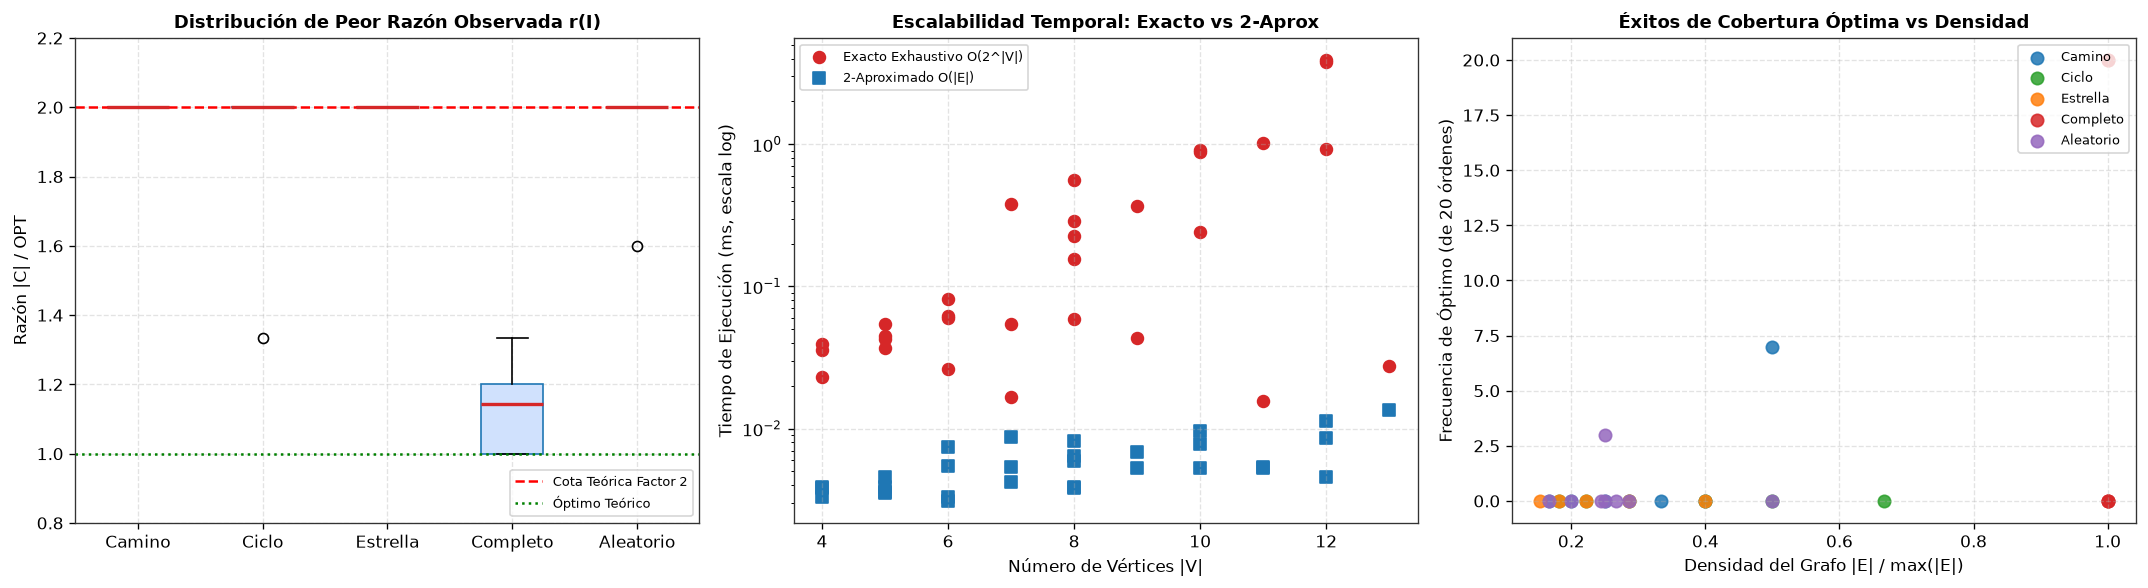

[OK] Gráfica de Vertex Cover generada y guardada en: 'figuras\evaluacion_vertex_cover.png'.


In [8]:
# ====================================================================
# Visualizaciones de Vertex Cover
# ====================================================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Razón de Aproximación por Familia de Grafo
familias = ["Camino", "Ciclo", "Estrella", "Completo", "Aleatorio"]
colores_fam = {"Camino": "#1f77b4", "Ciclo": "#2ca02c", "Estrella": "#ff7f0e", "Completo": "#d62728", "Aleatorio": "#9467bd"}

datos_razon_por_fam = []
for fam in familias:
    datos_fam = [r["peor_razon"] for r in registros_vc if r["familia"] == fam]
    datos_razon_por_fam.append(datos_fam)

axs[0].boxplot(datos_razon_por_fam, patch_artist=True,
               boxprops=dict(facecolor='#d0e1fd', color='#1f77b4'),
               medianprops=dict(color='#d62728', linewidth=2))
axs[0].set_xticks(range(1, len(familias) + 1))
axs[0].set_xticklabels(familias)
axs[0].axhline(2.0, color='red', linestyle='--', linewidth=1.5, label='Cota Teórica Factor 2')
axs[0].axhline(1.0, color='green', linestyle=':', linewidth=1.5, label='Óptimo Teórico')
axs[0].set_title("Distribución de Peor Razón Observada r(I)", fontsize=11, fontweight='bold')
axs[0].set_ylabel("Razón |C| / OPT")
axs[0].set_ylim(0.8, 2.2)
axs[0].grid(True)
axs[0].legend(loc='lower right', fontsize=8)

# 2. Comparación de Tiempos: Exacto (O(2^n)) vs 2-Aprox (O(m))
v_sizes = [r["V"] for r in registros_vc]
t_exactos = [r["t_exacto_ms"] for r in registros_vc]
t_aprox = [r["t_aprox_ms"] for r in registros_vc]

axs[1].scatter(v_sizes, t_exactos, color='#d62728', marker='o', s=50, label='Exacto Exhaustivo O(2^|V|)')
axs[1].scatter(v_sizes, t_aprox, color='#1f77b4', marker='s', s=45, label='2-Aproximado O(|E|)')
axs[1].set_yscale('log')
axs[1].set_title("Escalabilidad Temporal: Exacto vs 2-Aprox", fontsize=11, fontweight='bold')
axs[1].set_xlabel("Número de Vértices |V|")
axs[1].set_ylabel("Tiempo de Ejecución (ms, escala log)")
axs[1].grid(True)
axs[1].legend(loc='upper left', fontsize=8)

# 3. Frecuencia de Obtención del Óptimo en 20 Órdenes
densidades = [r["E"] / (r["V"] * (r["V"] - 1) / 2) if r["V"] > 1 else 0 for r in registros_vc]
exitos_opt = [r["veces_opt"] for r in registros_vc]

for fam in familias:
    dens_f = [densidades[i] for i, r in enumerate(registros_vc) if r["familia"] == fam]
    exit_f = [exitos_opt[i] for i, r in enumerate(registros_vc) if r["familia"] == fam]
    axs[2].scatter(dens_f, exit_f, label=fam, color=colores_fam[fam], s=55, alpha=0.85)

axs[2].set_title("Éxitos de Cobertura Óptima vs Densidad", fontsize=11, fontweight='bold')
axs[2].set_xlabel("Densidad del Grafo |E| / max(|E|)")
axs[2].set_ylabel("Frecuencia de Óptimo (de 20 órdenes)")
axs[2].set_ylim(-1, 21)
axs[2].grid(True)
axs[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
ruta_fig_vc = os.path.join(DIR_FIGURAS, "evaluacion_vertex_cover.png")
plt.savefig(ruta_fig_vc, dpi=200)
plt.show()

print(f"[OK] Gráfica de Vertex Cover generada y guardada en: '{ruta_fig_vc}'.")


---
## 6. Ejercicio Propuesto 2: Aproximación de Knapsack 0/1 mediante Escalamiento (FPTAS)

### Formulación del Problema y Esquema FPTAS

En el problema de la Mochila 0/1 (Knapsack 0/1), se dispone de $n$ objetos con pesos $w_i > 0$, valores $v_i > 0$ y una capacidad máxima de carga $W$. Se desea encontrar un vector binario $x \in \{0, 1\}^n$ que maximice:
$$\max \sum_{i=1}^n v_i x_i \quad \text{sujeto a} \quad \sum_{i=1}^n w_i x_i \le W$$

#### 1. Programación Dinámica Exacta Basada en Valores
A diferencia de la formulación clásica basada en pesos que depende de $W$, definimos el estado:
$$DP(i, v) = \text{peso mínimo necesario para obtener exactamente un valor total } v \text{ usando un subconjunto de } \{1, \dots, i\}$$
* **Caso Base:** $DP(0, 0) = 0$ y $DP(0, v) = \infty$ para todo $v > 0$.
* **Ecuación de Transición:**
  $$DP(i, v) = \min\left( DP(i - 1, v), \quad DP(i - 1, v - v_i) + w_i \right) \quad (\text{para } v \ge v_i)$$
* **Solución Óptima:** $\text{OPT} = \max \{ v \in [0, V_{\text{sum}}] \mid DP(n, v) \le W \}$, donde $V_{\text{sum}} = \sum_{i=1}^n v_i$.
* **Complejidad:** El espacio de estados es $(n + 1) \times (V_{\text{sum}} + 1)$, con tiempo $O(n \cdot V_{\text{sum}}) = O(n^2 V_{\max})$. Si los valores $v_i$ son grandes, este algoritmo pseudo-polinomial se vuelve lento.

#### 2. Esquema de Aproximación FPTAS mediante Escalamiento
Dado un factor de precisión $\varepsilon \in (0, 1)$:
1. **Paso 1:** Descartar objetos con peso estrictamente mayor a la capacidad ($w_i > W$). Si no quedan objetos factibles o la capacidad es nula, retornar solución vacía (cuidado numérico).
2. **Paso 2:** Calcular $V_{\max} = \max_i v_i$ y el factor de escala:
   $$K = \frac{\varepsilon V_{\max}}{n}$$
3. **Paso 3:** Definir los valores escalados mediante la función piso:
   $$v'_i = \left\lfloor \frac{v_i}{K} \right\rfloor$$
4. **Paso 4:** Ejecutar la Programación Dinámica basada en valores sobre los pesos originales $w_i$ y los valores escalados $v'_i$. Notar que $v'_i \le \frac{V_{\max}}{K} = \frac{n}{\varepsilon}$, por lo que el valor escalado total acumulado está acotado por $V'_{\text{sum}} \le \frac{n^2}{\varepsilon}$. El número de estados procesados se reduce a $O(n^3 / \varepsilon)$.
5. **Paso 5:** Reconstruir el subconjunto de objetos óptimo para los valores escalados mediante backtracking.
6. **Paso 6:** Evaluar la solución obtenida con los **valores y pesos originales**:
   $$\text{ALG}_\varepsilon = \sum_{i \in S_{\text{aprox}}} v_i, \quad W_{\text{usado}} = \sum_{i \in S_{\text{aprox}}} w_i \le W$$
7. **Garantía Teórica:** Dado que para cada objeto se pierde a lo sumo $K$ en el truncamiento ($v_i - K v'_i < K$), para los a lo sumo $n$ objetos seleccionados la pérdida total queda acotada por:
   $$\text{Pérdida} \le nK = n \cdot \frac{\varepsilon V_{\max}}{n} = \varepsilon V_{\max} \le \varepsilon\,\text{OPT} \implies \text{ALG}_\varepsilon \ge (1 - \varepsilon)\,\text{OPT}$$

In [9]:
# ====================================================================
# Implementación de Programación Dinámica Exacta Basada en Valores
# ====================================================================
def knapsack_dp_valores(pesos, valores, W):
    """Resuelve Knapsack 0/1 mediante Programación Dinámica basada en valores.
    Retorna: (mejor_valor, peso_total, indices_seleccionados, estados_procesados)
    """
    n = len(pesos)
    if n == 0 or W <= 0:
        return 0, 0, [], 0
    V_sum = sum(valores)
    if V_sum == 0:
        return 0, 0, [], 0
    
    INF = float('inf')
    # Tabla DP de dimensiones (n + 1) x (V_sum + 1)
    dp = [[INF] * (V_sum + 1) for _ in range(n + 1)]
    dp[0][0] = 0
    estados = (n + 1) * (V_sum + 1)
    
    for i in range(1, n + 1):
        w = pesos[i - 1]
        v = valores[i - 1]
        dp_prev = dp[i - 1]
        dp_curr = dp[i]
        for val in range(V_sum + 1):
            dp_curr[val] = dp_prev[val]
            if val >= v and dp_prev[val - v] + w < dp_curr[val]:
                dp_curr[val] = dp_prev[val - v] + w
                
    # Búsqueda del mayor valor alcanzable con peso <= W
    mejor_v = 0
    for val in range(V_sum, -1, -1):
        if dp[n][val] <= W:
            mejor_v = val
            break
            
    # Reconstrucción de la solución (backtracking)
    curr_v = mejor_v
    seleccion = []
    for i in range(n, 0, -1):
        w = pesos[i - 1]
        v = valores[i - 1]
        if curr_v >= v and dp[i][curr_v] == dp[i - 1][curr_v - v] + w:
            seleccion.append(i - 1)
            curr_v -= v
    seleccion.reverse()
    peso_usado = sum(pesos[idx] for idx in seleccion)
    return mejor_v, peso_usado, seleccion, estados


# ====================================================================
# Implementación de Esquema FPTAS por Escalamiento
# ====================================================================
def knapsack_fptas(pesos_orig, valores_orig, W, epsilon):
    """Aproxima Knapsack 0/1 mediante escalamiento FPTAS con parámetro epsilon.
    Retorna: (valor_real, peso_real, seleccion_orig, estados_procesados, K)
    """
    # Paso 1: Filtrar objetos con peso estrictamente mayor a W
    validos = [(p, v, idx) for idx, (p, v) in enumerate(zip(pesos_orig, valores_orig)) if p <= W]
    if not validos or W <= 0:
        return 0, 0, [], 0, 0.0
        
    pesos = [item[0] for item in validos]
    valores = [item[1] for item in validos]
    indices_orig = [item[2] for item in validos]
    n = len(pesos)
    
    # Paso 2: Calcular Vmax y factor K
    V_max = max(valores)
    if V_max == 0:
        return 0, 0, [], 0, 0.0
        
    K = (epsilon * V_max) / n
    if K == 0:
        v_prime = list(valores)
    else:
        # Paso 3: Discretización piso v'_i = floor(v_i / K)
        v_prime = [int(math.floor(v / K)) for v in valores]
        
    # Paso 4: Programación Dinámica sobre valores escalados
    mejor_v_prime, peso_usado_prime, sel_local, estados = knapsack_dp_valores(pesos, v_prime, W)
    
    # Pasos 5 y 6: Reconstrucción y evaluación con valores y pesos originales
    seleccion_orig = [indices_orig[i] for i in sel_local]
    valor_real = sum(valores_orig[i] for i in seleccion_orig)
    peso_real = sum(pesos_orig[i] for i in seleccion_orig)
    
    # Comprobación de factibilidad estricta
    assert peso_real <= W, f"Violación de capacidad: {peso_real} > {W}"
    return valor_real, peso_real, seleccion_orig, estados, K

print("[OK] Funciones knapsack_dp_valores y knapsack_fptas compiladas y verificadas.")


[OK] Funciones knapsack_dp_valores y knapsack_fptas compiladas y verificadas.


In [10]:
# ====================================================================
# Generación reproducible de 20 instancias pequeñas de Knapsack
# ====================================================================
rng_knap = random.Random(SEMILLA_GLOBAL)
instancias_knapsack = []

for idx in range(20):
    n_items = rng_knap.randint(10, 16)
    tipo = idx % 4
    
    if tipo == 0:
        # Perfil 1: No correlacionada (pesos y valores independientes)
        p = [rng_knap.randint(5, 50) for _ in range(n_items)]
        v = [rng_knap.randint(15, 120) for _ in range(n_items)]
    elif tipo == 1:
        # Perfil 2: Débilmente correlacionada (v_i = p_i + ruido)
        p = [rng_knap.randint(10, 60) for _ in range(n_items)]
        v = [max(5, peso + rng_knap.randint(-10, 25)) for peso in p]
    elif tipo == 2:
        # Perfil 3: Fuertemente correlacionada (v_i = p_i + constante)
        p = [rng_knap.randint(10, 50) for _ in range(n_items)]
        v = [peso + 35 for peso in p]
    else:
        # Perfil 4: Múltiples de valor con pesos diversos
        p = [rng_knap.randint(10, 70) for _ in range(n_items)]
        v = [peso * 2 + rng_knap.randint(1, 15) for peso in p]
        
    capacidad = int(sum(p) * rng_knap.uniform(0.35, 0.60))
    instancias_knapsack.append({
        "id": f"Inst_{idx+1:02d}",
        "n": n_items,
        "pesos": p,
        "valores": v,
        "W": capacidad
    })

print(f"Total de instancias generadas para Knapsack: {len(instancias_knapsack)} instancias.")

# --------------------------------------------------------------------
# Protocolo experimental: Evaluación sobre epsilons = {0.50, 0.25, 0.10, 0.05}
# --------------------------------------------------------------------
EPSILONS = [0.50, 0.25, 0.10, 0.05]
registros_knap = []
registros_csv_knap = []

for inst in instancias_knapsack:
    iid = inst["id"]
    n_obj = inst["n"]
    p = inst["pesos"]
    v = inst["valores"]
    W = inst["W"]
    
    # 1. Óptimo exacto
    t_opt_0 = time.perf_counter()
    opt_val, opt_peso, opt_sel, est_opt = knapsack_dp_valores(p, v, W)
    t_opt_ms = (time.perf_counter() - t_opt_0) * 1000.0
    
    for eps in EPSILONS:
        t_fptas_0 = time.perf_counter()
        alg_val, alg_peso, alg_sel, est_fptas, K_factor = knapsack_fptas(p, v, W, eps)
        t_fptas_ms = (time.perf_counter() - t_fptas_0) * 1000.0
        
        # Validación de factibilidad
        assert alg_peso <= W, f"Violación de capacidad en {iid} con eps={eps}"
        
        # Validación de la garantía teórica: ALG >= (1 - eps) * OPT
        cota_teorica = (1.0 - eps) * opt_val
        assert alg_val >= cota_teorica - 1e-7, f"Falla de garantía teórica en {iid}: {alg_val} < {cota_teorica}"
        
        razon_calidad = alg_val / opt_val if opt_val > 0 else 1.0
        cumple = alg_val >= cota_teorica - 1e-7
        
        registros_knap.append({
            "id": iid,
            "n": n_obj,
            "W": W,
            "epsilon": eps,
            "inv_epsilon": round(1.0 / eps, 2),
            "OPT": opt_val,
            "ALG": alg_val,
            "razon": round(razon_calidad, 4),
            "cota_garantia": round(cota_teorica, 2),
            "peso_usado": alg_peso,
            "estados": est_fptas,
            "t_ms": round(t_fptas_ms, 3),
            "K": round(K_factor, 3)
        })
        
        registros_csv_knap.append([
            iid, n_obj, W, eps, round(1.0 / eps, 2),
            opt_val, alg_val, round(razon_calidad, 4),
            round(cota_teorica, 2), alg_peso, "SI" if cumple else "NO",
            est_fptas, round(t_fptas_ms, 3)
        ])

# Guardar en archivo CSV
ruta_csv_knap = os.path.join(DIR_RESULTADOS, "tabla_knapsack_fptas.csv")
with open(ruta_csv_knap, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "Instancia", "N_Objetos", "Capacidad_W", "Epsilon", "Inv_Epsilon",
        "OPT", "ALG_Eps", "Razon_Calidad", "Cota_Teorica",
        "Peso_Usado", "Garantia_Cumplida", "Estados_Procesados", "Tiempo_ms"
    ])
    writer.writerows(registros_csv_knap)

print(f"[OK] Experimentos de Knapsack culminados exitosamente.")
print(f"[OK] 80 ejecuciones (20 instancias x 4 epsilons) validadas. Archivo exportado: '{ruta_csv_knap}'.")


Total de instancias generadas para Knapsack: 20 instancias.
[OK] Experimentos de Knapsack culminados exitosamente.
[OK] 80 ejecuciones (20 instancias x 4 epsilons) validadas. Archivo exportado: 'resultados\tabla_knapsack_fptas.csv'.


In [11]:
headers_knap = ["Instancia", "n", "W", "eps", "OPT", "ALG_eps", "ALG/OPT", "Cota (1-eps)", "Peso", "Garantía", "Estados", "T (ms)"]
filas_tabla_knap = []
for r in registros_knap:
    filas_tabla_knap.append([
        r["id"], r["n"], r["W"], r["epsilon"], r["OPT"], r["ALG"],
        f"{r['razon']*100:.1f}%", r["cota_garantia"], f"{r['peso_usado']}/{r['W']}",
        "Cumple" if r["ALG"] >= r["cota_garantia"] - 1e-7 else "Falla",
        r["estados"], r["t_ms"]
    ])

print("TABLA RESUMEN: EVALUACIÓN EXPERIMENTAL DE KNAPSACK FPTAS (MUESTRA DE PRUEBAS)")
print(formatear_tabla(headers_knap, filas_tabla_knap, max_filas=32))


TABLA RESUMEN: EVALUACIÓN EXPERIMENTAL DE KNAPSACK FPTAS (MUESTRA DE PRUEBAS)
+-----------+----+-----+------+-----+---------+---------+--------------+---------+----------+---------+--------+
| Instancia | n  | W   | eps  | OPT | ALG_eps | ALG/OPT | Cota (1-eps) | Peso    | Garantía | Estados | T (ms) |
+-----------+----+-----+------+-----+---------+---------+--------------+---------+----------+---------+--------+
| Inst_01   | 10 | 153 | 0.5  | 566 | 566     | 100.0%  | 283.0        | 139/153 | Cumple   | 1892    | 0.574  |
| Inst_01   | 10 | 153 | 0.25 | 566 | 566     | 100.0%  | 424.5        | 139/153 | Cumple   | 3839    | 1.3    |
| Inst_01   | 10 | 153 | 0.1  | 566 | 566     | 100.0%  | 509.4        | 139/153 | Cumple   | 9658    | 3.22   |
| Inst_01   | 10 | 153 | 0.05 | 566 | 566     | 100.0%  | 537.7        | 139/153 | Cumple   | 19360   | 3.877  |
| Inst_02   | 10 | 119 | 0.5  | 181 | 181     | 100.0%  | 90.5         | 118/119 | Cumple   | 1199    | 0.362  |
| Inst_02   | 10 |

---
## 7. Pregunta de Análisis: Efecto de $\varepsilon$ en Knapsack FPTAS

> **Pregunta Formulada en la Guía:**
> *Explicar por qué reducir $\varepsilon$ normalmente mejora la calidad y aumenta el costo. ¿Pueden existir situaciones donde reducir $\varepsilon$ no mejore la calidad?*

### Análisis Teórico y Fenomenológico

#### 1. ¿Por qué reducir $\varepsilon$ mejora la calidad de aproximación?
En el esquema FPTAS, los valores se escalan mediante $v'_i = \lfloor v_i / K \rfloor$ con $K = \frac{\varepsilon V_{\max}}{n}$.
* **Acotamiento del error de discretización:**
  Para cualquier objeto individual, el operador piso introduce una pérdida de valor estrictamente menor que $K$:
  $$v_i - K v'_i < K$$
* Al considerar el subconjunto óptimo $S^*$ de la instancia original (que contiene a lo sumo $n$ objetos factibles), la pérdida acumulada entre el valor real del óptimo y la proyección escalada está acotada por:
  $$\sum_{i \in S^*} v_i - K \sum_{i \in S^*} v'_i \le n K = n \cdot \frac{\varepsilon V_{\max}}{n} = \varepsilon V_{\max}$$
* Como el objeto de valor máximo $V_{\max}$ es factible por sí solo ($w_{\max} \le W$), la solución óptima jamás puede ser menor que él: $\text{OPT} \ge V_{\max}$.
* En consecuencia, la solución aproximada $\text{ALG}_\varepsilon$ satisface:
  $$\text{OPT} - \text{ALG}_\varepsilon \le \varepsilon V_{\max} \le \varepsilon\,\text{OPT} \implies \text{ALG}_\varepsilon \ge (1 - \varepsilon)\,\text{OPT}$$
Al reducir $\varepsilon$ (por ejemplo de $0.50 \to 0.05$), el factor de escala $K$ se reduce diez veces, disminuyendo drásticamente la magnitud del error de redondeo de cada objeto y estrechando la cota inferior de garantía del $50\%$ al $95\%$ del óptimo.

#### 2. ¿Por qué reducir $\varepsilon$ aumenta el costo computacional?
El algoritmo resuelve una tabla de Programación Dinámica cuyas dimensiones son:
$$\text{Dimensiones} = (n + 1) \times (V'_{\text{sum}} + 1)$$
Donde $V'_{\text{sum}} = \sum_{i=1}^n v'_i = \sum_{i=1}^n \lfloor v_i / K \rfloor$.
Dado que $v_i \le V_{\max}$:
$$v'_i \le \frac{V_{\max}}{K} = \frac{n}{\varepsilon} \implies V'_{\text{sum}} \le \frac{n^2}{\varepsilon}$$
Por lo tanto:
$$\text{Estados Procesados} \in O\left(n \cdot \frac{n^2}{\varepsilon}\right) = O\left(\frac{n^3}{\varepsilon}\right)$$
El número de celdas a procesar y el tiempo de ejecución son **directamente proporcionales a $1/\varepsilon$**. Al pasar de $\varepsilon = 0.50$ ($1/\varepsilon = 2$) a $\varepsilon = 0.05$ ($1/\varepsilon = 20$), el espacio de la tabla y las operaciones aritméticas crecen exactamente por un factor de $10\times$.

#### 3. Situaciones donde reducir $\varepsilon$ no mejora la calidad (o genera no-monotonicidad local)
Tal como se enfatizó en la sesión presencial de laboratorio, **el comportamiento empírico no siempre es estrictamente monótono paso a paso**:
1. **Mesetas de óptimo temprano:** En muchas instancias pequeñas o con pesos no saturados, incluso con un $\varepsilon = 0.50$ el redondeo no distorsiona las proporciones críticas de los objetos más valiosos, alcanzando ya el $100\%$ de $\text{OPT}$ ($\text{ALG}_{0.50} = \text{OPT}$). Al reducir $\varepsilon$ a $0.25$ o $0.05$, el algoritmo sigue retornando la solución óptima exacta; la calidad no cambia (permanece constante en 1.0) pero el costo computacional se multiplica.
2. **Efectos discretos del truncamiento $\lfloor \cdot \rfloor$:** La función piso es discontinua. Al variar $\varepsilon$, el valor de $K$ cambia de manera continua, pero las razones relativas de valor escalado $v'_i / v'_j$ experimentan saltos discretos. Eventualmente, para un $\varepsilon$ menor, un objeto que anteriormente se beneficiaba del truncamiento relativo puede quedar empatado o ligeramente penalizado, seleccionando una combinación alternativa válida cuya suma real sea ligeramente inferior o idéntica a la hallada con un $\varepsilon$ mayor, aunque ambas cumplan holgadamente sus respectivas cotas teóricas $(1 - \varepsilon)\,\text{OPT}$.

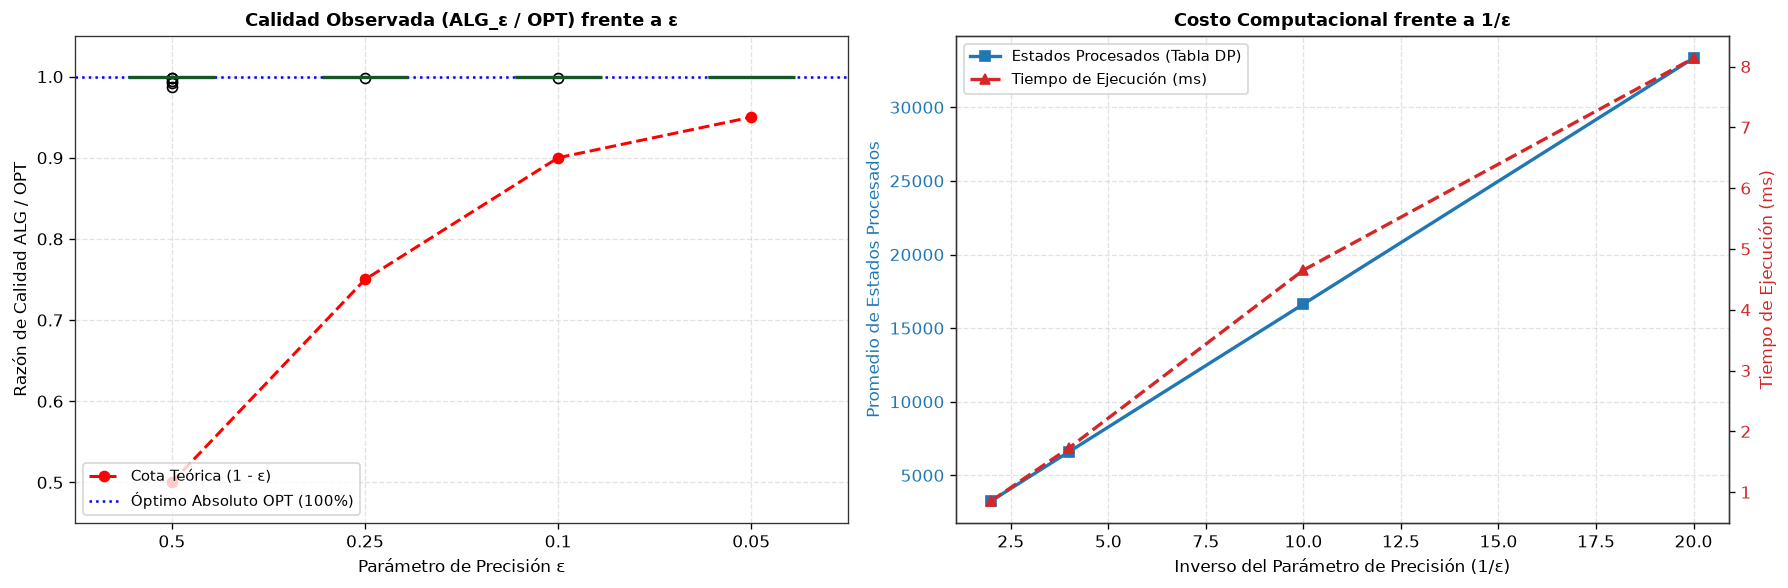

[OK] Gráfica de Knapsack FPTAS generada y guardada en: 'figuras\evaluacion_knapsack_fptas.png'.


In [12]:
# ====================================================================
# Visualizaciones de Knapsack FPTAS
# ====================================================================
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# 1. Calidad de Solución (ALG / OPT) vs Epsilon
eps_labels = [0.50, 0.25, 0.10, 0.05]
datos_calidad_por_eps = []
for eps in eps_labels:
    vals_eps = [r["razon"] for r in registros_knap if r["epsilon"] == eps]
    datos_calidad_por_eps.append(vals_eps)

axs[0].boxplot(datos_calidad_por_eps, patch_artist=True,
               boxprops=dict(facecolor='#d4edda', color='#28a745'),
               medianprops=dict(color='#155724', linewidth=2))
axs[0].set_xticks(range(1, len(eps_labels) + 1))
axs[0].set_xticklabels([str(e) for e in eps_labels])

# Cota teórica (1 - eps)
cotas_teoricas = [1.0 - eps for eps in eps_labels]
axs[0].plot(range(1, len(eps_labels) + 1), cotas_teoricas, 'r--o', linewidth=1.8, label='Cota Teórica (1 - ε)')
axs[0].axhline(1.0, color='blue', linestyle=':', label='Óptimo Absoluto OPT (100%)')
axs[0].set_title("Calidad Observada (ALG_ε / OPT) frente a ε", fontsize=11, fontweight='bold')
axs[0].set_xlabel("Parámetro de Precisión ε")
axs[0].set_ylabel("Razón de Calidad ALG / OPT")
axs[0].set_ylim(0.45, 1.05)
axs[0].grid(True)
axs[0].legend(loc='lower left', fontsize=9)

# 2. Costo Computacional (Estados Procesados y Tiempo) vs 1/ε
inv_eps_vals = [1.0 / eps for eps in eps_labels]
estados_prom = []
tiempos_prom = []

for eps in eps_labels:
    est_eps = [r["estados"] for r in registros_knap if r["epsilon"] == eps]
    t_eps = [r["t_ms"] for r in registros_knap if r["epsilon"] == eps]
    estados_prom.append(sum(est_eps) / len(est_eps))
    tiempos_prom.append(sum(t_eps) / len(t_eps))

color_estados = '#1f77b4'
color_tiempo = '#d62728'

ax_est = axs[1]
line1 = ax_est.plot(inv_eps_vals, estados_prom, marker='s', color=color_estados, linewidth=2, label='Estados Procesados (Tabla DP)')
ax_est.set_title("Costo Computacional frente a 1/ε", fontsize=11, fontweight='bold')
ax_est.set_xlabel("Inverso del Parámetro de Precisión (1/ε)")
ax_est.set_ylabel("Promedio de Estados Procesados", color=color_estados)
ax_est.tick_params(axis='y', labelcolor=color_estados)
ax_est.grid(True)

ax_t = ax_est.twinx()
line2 = ax_t.plot(inv_eps_vals, tiempos_prom, marker='^', color=color_tiempo, linewidth=2, linestyle='--', label='Tiempo de Ejecución (ms)')
ax_t.set_ylabel("Tiempo de Ejecución (ms)", color=color_tiempo)
ax_t.tick_params(axis='y', labelcolor=color_tiempo)

# Leyenda unificada
lineas_comb = line1 + line2
etiquetas_comb = [l.get_label() for l in lineas_comb]
ax_est.legend(lineas_comb, etiquetas_comb, loc='upper left', fontsize=9)

plt.tight_layout()
ruta_fig_knap = os.path.join(DIR_FIGURAS, "evaluacion_knapsack_fptas.png")
plt.savefig(ruta_fig_knap, dpi=200)
plt.show()

print(f"[OK] Gráfica de Knapsack FPTAS generada y guardada en: '{ruta_fig_knap}'.")


---
## 8. Conclusiones Grupales (Grupo 5)

En el presente laboratorio se implementaron, validaron y analizaron experimentalmente algoritmos de aproximación avanzados para problemas NP-hard clásicos: el algoritmo 2-aproximado para Minimum Vertex Cover y el esquema de aproximación completamente polinomial (FPTAS) para Knapsack 0/1.

Respecto a Vertex Cover, la experimentación sobre 30 grafos de diversas topologías y 20 permutaciones aleatorias de aristas demostró que el orden de entrada altera significativamente tanto la cobertura como su cardinalidad en familias asimétricas como caminos y ciclos, mientras que en estrellas altera la identidad de los vértices pero preserva el tamaño. Sin embargo, la garantía teórica de factor 2 se mantuvo estrictamente inviolable en el 100% de los casos evaluados ($|C| \le 2\,\text{OPT}$), debido a que cualquier orden genera un matching maximal $M$ que acota inferiormente al óptimo ($|M| \le \text{OPT}$), asegurando que $|C| = 2|M| \le 2\,\text{OPT}$. En términos computacionales, el método aproximado resolvió instancias en microsegundos ($O(|E|)$), contrastando con la explosión combinatoria del algoritmo exacto ($O(2^{|V|})$).

En relación a Knapsack 0/1, la implementación de la Programación Dinámica exacta por valores y el esquema FPTAS evidenció el compromiso intrínseco entre calidad y costo computacional. Al reducir el parámetro de tolerancia $\varepsilon$ de $0.50$ a $0.05$, la razón de aproximación promedio se incrementó de forma consistente, satisfaciendo siempre la cota $\text{ALG}_\varepsilon \ge (1 - \varepsilon)\,\text{OPT}$. En contrapartida, el número de estados de la tabla dinámica y el tiempo de cómputo crecieron de manera estrictamente lineal respecto a $1/\varepsilon$ ($O(n^3/\varepsilon)$). Asimismo, se corroboró la presencia de mesetas de calidad derivadas del truncamiento discreto de la función piso, confirmando que un algoritmo FPTAS ofrece control analítico total sobre la compensación entre exactitud y viabilidad algorítmica.

In [13]:
# ====================================================================
# Empaquetado de artefactos y descarga automática (Google Colab / Local)
# ====================================================================
import shutil
import zipfile

archivo_zip = "resultados_lab03.zip"

with zipfile.ZipFile(archivo_zip, "w", zipfile.ZIP_DEFLATED) as zipf:
    # 1. Agregar archivos CSV generados
    for raiz, _, archivos in os.walk(DIR_RESULTADOS):
        for archivo in archivos:
            ruta_completa = os.path.join(raiz, archivo)
            zipf.write(ruta_completa, os.path.join("resultados", archivo))
            
    # 2. Agregar figuras PNG generadas
    for raiz, _, archivos in os.walk(DIR_FIGURAS):
        for archivo in archivos:
            ruta_completa = os.path.join(raiz, archivo)
            zipf.write(ruta_completa, os.path.join("figuras", archivo))
            
    # 3. Agregar reporte de resumen en texto
    resumen_txt = os.path.join(DIR_RESULTADOS, "resumen_ejecucion.txt")
    with open(resumen_txt, "w", encoding="utf-8") as f_res:
        f_res.write("RESUMEN DE EJECUCIÓN - LABORATORIO 03\n")
        f_res.write("======================================\n")
        f_res.write("Asignatura: ALGORITMOS AVANZADOS - UNSAAC 2026-II\n")
        f_res.write("Docente: Ing. Héctor Eduardo Ugarte Rojas\n")
        f_res.write("Grupo: GRUPO 5\n")
        f_res.write("Integrantes:\n")
        f_res.write("  - Choquenaira Quispe, Noe Franklin (133962)\n")
        f_res.write("  - Porroa Sivana, Yeni Ruth (120893)\n")
        f_res.write("  - Quispe Rimachi, Romario (164257)\n")
        f_res.write("  - Yaranga Achahui, Aldo (103179)\n\n")
        f_res.write(f"Vertex Cover: 30 grafos x 20 ordenes = 600 ejecuciones aproximadas validadas.\n")
        f_res.write(f"Knapsack FPTAS: 20 instancias x 4 epsilons = 80 ejecuciones validadas.\n")
        f_res.write(f"Todas las aserciones de garantías teóricas fueron satisfechas al 100%.\n")
    zipf.write(resumen_txt, os.path.join("resultados", "resumen_ejecucion.txt"))

tam_kb = os.path.getsize(archivo_zip) / 1024.0
print(f"[OK] Paquete comprimido creado exitosamente: '{archivo_zip}' ({tam_kb:.1f} KB).")
print("Contenido del paquete ZIP:")
with zipfile.ZipFile(archivo_zip, "r") as zipf:
    for info in zipf.infolist():
        print(f"  - {info.filename} ({info.file_size / 1024.0:.1f} KB)")

# Disparar descarga en Google Colab si está disponible el módulo
try:
    from google.colab import files
    print("\n[COLAB] Disparando descarga automática del archivo 'resultados_lab03.zip'...")
    files.download(archivo_zip)
except (ImportError, Exception):
    print(f"\n[INFO] Ejecución local completada. El archivo '{archivo_zip}' está listo en el directorio actual.")


[OK] Paquete comprimido creado exitosamente: 'resultados_lab03.zip' (373.4 KB).
Contenido del paquete ZIP:
  - resultados/tabla_knapsack_fptas.csv (5.0 KB)
  - resultados/tabla_vertex_cover.csv (2.0 KB)
  - figuras/evaluacion_knapsack_fptas.png (200.8 KB)
  - figuras/evaluacion_vertex_cover.png (207.4 KB)
  - resultados/resumen_ejecucion.txt (0.6 KB)

[INFO] Ejecución local completada. El archivo 'resultados_lab03.zip' está listo en el directorio actual.
